In [1]:
from pathlib import Path

import sys
# Add src to path for importing local modules
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from trompy import save_figure_atomic

from src.outlier_filter import robust_tail_filter_log_area

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams['savefig.transparent'] = True

SAVEFIGS = True

In [2]:
DATAFOLDER = Path("./data")
METAFILE = Path("./data/fenestrations_metafile.xlsx")
FIGSFOLDER = Path("./figs/paper1/panels")
IMAGESFOLDER = Path("C:/Users/jmc010/Data/fenestrations/images")
SEGFOLDER = Path("C:/Users/jmc010/Data/fenestrations/flatten_npy")

# Ensure output folder exists for direct saves.
FIGSFOLDER.mkdir(parents=True, exist_ok=True)

# save_figure_atomic stages files under _tmp/<relative output path>;
# ensure that staging path exists when using relative figure folders.
(Path.cwd() / "_tmp" / FIGSFOLDER).mkdir(parents=True, exist_ok=True)

data = pd.read_pickle(DATAFOLDER / "roi_data.pickle")

# Extract the DataFrames
rois_df = data['rois']
summary_df = data['summary']

# load metafile
metadata = pd.read_excel(METAFILE)

print("ROI Data Statistics")
print("=" * 50)
print(f"\nROIs DataFrame:")
print(f"  Rows: {len(rois_df)}")
print(f"  Columns: {len(rois_df.columns)}")
print(f"  Column names: {list(rois_df.columns)}")
print(f"\n  Memory usage: {rois_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n\nSummary DataFrame:")
print(f"  Rows: {len(summary_df)}")
print(f"  Columns: {len(summary_df.columns)}")
print(f"  Column names: {list(summary_df.columns)}")
print(f"\n  Memory usage: {summary_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 50)
print("\nFirst few rows of ROIs DataFrame:")
print(rois_df.head())

print("\n" + "=" * 50)
print("\nFirst few rows of Summary DataFrame:")
print(summary_df.head())

print("\n" + "=" * 50)
print("\nData types:")
print("\nROIs DataFrame:")
print(rois_df.dtypes)
print("\nSummary DataFrame:")
print(summary_df.dtypes)

ROI Data Statistics

ROIs DataFrame:
  Rows: 234865
  Columns: 33
  Column names: ['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count', 'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids', 'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg', 'cluster_is_convex', 'cluster_center_inside_polygon', 'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major', 'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean', 'major_axis_angle', 'major_axis_extent', 'minor_axis_extent', 'major_axis_length_px', 'minor_axis_length_px', 'step_major', 'step_minor', 'step_diag45', 'step_diag135', 'diameter_area', 'experiment', 'condition']

  Memory usage: 262.44 MB


Summary DataFrame:
  Rows: 548
  Columns: 20
  Column names: ['id', 'stub', 'mean_neighbor_count', 'mean_cluster_neighbor_distance_px', 'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2', 'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm', 'mean_diameter_major_nm', 'mean

In [42]:
def get_filtered_control_data(rois_df, summary_df):
    
    rois_df, _ = robust_tail_filter_log_area(rois_df)
    rois_df = rois_df.query("condition == 'control'").reset_index(drop=True)
    summary_df = summary_df.query("condition == 'control'").reset_index(drop=True)
    
    return rois_df, summary_df

rois_df, summary_df = get_filtered_control_data(rois_df, summary_df)

In [126]:
# setting plotting conventions

def init_diameter_panel():
    f, ax = plt.subplots(figsize=(1.5, 1.2),
                         gridspec_kw={"left": 0.25, "right": 0.85, "top": 0.95, "bottom": 0.37})
    
    return f, ax

diameter_color = "steelblue"
circularity_color = "coral"
minor_color = "seagreen"
major_color = "mediumpurple"
neighbor_color = "goldenrod"

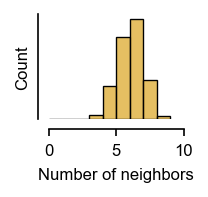

In [127]:
## cluster and neighbour panels

f, ax = init_diameter_panel()

sns.histplot(data=rois_df.cluster_neighbor_count, ax=ax,
             bins=np.arange(0,10,1),
             color=neighbor_color, alpha=0.7,
            )

ax.set_xlabel("Number of neighbors")
ax.set_xlim(0, 10)
ax.set_yticks([])

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "n_neighbors")


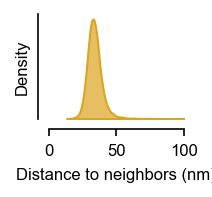

In [128]:
## cluster and neighbour panels

f, ax = init_diameter_panel()

sns.kdeplot(data=rois_df.cluster_neighbor_distance, ax=ax,
            fill=True, color=neighbor_color, alpha=0.7,
            cut=0
            )

ax.set_xlabel("Distance to neighbors (nm)")
ax.set_xlim(0, 100)
ax.set_yticks([])

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "neighbor_distance")

In [129]:
rois_df.head()

,id,stub,roi_id,centroid_x,centroid_y,pixel_count,pixel_size,area,cluster_neighbor_count,cluster_neighbor_ids,...,major_axis_length_px,minor_axis_length_px,step_major,step_minor,step_diag45,step_diag135,diameter_area,experiment,condition,robust_z_log_area
0,PR11,PR11_ME_03,1,780.653846,3.346154,52,3.616,679.923712,NaN,NaN,...,37.946239,26.533560,0.148809,0.104053,0.126588,0.132911,29.422878,protein,control,-3.048330
1,PR11,PR11_ME_03,2,275.217822,8.603960,101,3.616,1320.621056,NaN,NaN,...,51.998856,39.389873,0.203917,0.154470,0.174529,0.172030,41.005694,protein,control,-0.811032
2,PR11,PR11_ME_03,3,357.560000,10.946667,75,3.616,980.659200,NaN,NaN,...,43.265982,33.317531,0.169671,0.130657,0.156974,0.144136,35.335734,protein,control,-1.814068
3,PR11,PR11_ME_03,4,443.353383,15.488722,133,3.616,1739.035648,NaN,NaN,...,68.468093,37.681571,0.268502,0.147771,0.197775,0.227138,47.055382,protein,control,0.116503
4,PR11,PR11_ME_03,5,610.021583,23.575540,139,3.616,1817.488384,NaN,NaN,...,55.713541,49.112276,0.218484,0.192597,0.192672,0.210243,48.105073,protein,control,0.265205


Selected ROI_ID: 113
Neighbor ROI IDs: [111, 93, 98, 120, 137, 133]
881 167
Crop size: 160 x 160 px
Crop size: 578.6 x 578.6 nm


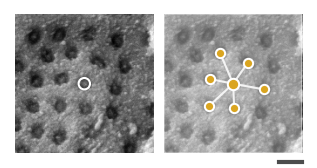

In [130]:
# example will use "PR_11_ME_14"
import ast

stub = "PR11_ME_14"

selected_rois = rois_df.query("stub == @stub").reset_index(drop=True)
if selected_rois.empty:
    raise ValueError(f"No ROIs found for stub: {stub}")

ROI_ID = np.random.choice(selected_rois.index)
ROI_ID = 113
print(f"Selected ROI_ID: {ROI_ID}")

centroid_x = int(selected_rois.loc[ROI_ID, "centroid_x"])
centroid_y = int(selected_rois.loc[ROI_ID, "centroid_y"])

neighbour_ids = selected_rois.loc[ROI_ID, "cluster_neighbor_ids"]
print(f"Neighbor ROI IDs: {neighbour_ids}")

tif_path = IMAGESFOLDER / f"{stub}.tif"
raw = tifffile.imread(tif_path)
seg = np.load(SEGFOLDER / f"{stub}_seg.npy", allow_pickle=True).item()

img = raw[0] if raw.ndim > 2 else raw

f, ax = plt.subplots(figsize=(2.5, 1.2), ncols=2, gridspec_kw={"width_ratios": [1, 1],
                                                             "wspace": 0.05,})

BORDER = 80

print(centroid_x, centroid_y)

# Proper crop bounds (old code had zero-height y slice)
x0 = max(centroid_x - BORDER, 0)
x1 = min(centroid_x + BORDER, img.shape[1])
y0 = max(centroid_y - BORDER, 0)
y1 = min(centroid_y + BORDER, img.shape[0])

crop = img[y0:y1, x0:x1]

# Print crop size in nm
if "pixel_size" in selected_rois.columns and pd.notna(selected_rois.loc[ROI_ID, "pixel_size"]):
    pixel_size_nm = float(selected_rois.loc[ROI_ID, "pixel_size"])
    crop_w_nm = crop.shape[1] * pixel_size_nm
    crop_h_nm = crop.shape[0] * pixel_size_nm
    print(f"Crop size: {crop.shape[1]} x {crop.shape[0]} px")
    print(f"Crop size: {crop_w_nm:.1f} x {crop_h_nm:.1f} nm")
else:
    print(f"Crop size: {crop.shape[1]} x {crop.shape[0]} px (pixel_size not found in selected_rois)")

# Left: crop only (no overlays)
ax[0].imshow(crop, cmap="gray")

# Right: same crop with faded background + overlays
ax[1].imshow(crop, cmap="gray")
ax[1].axhspan(0, crop.shape[0], xmin=0, xmax=1, color="white", alpha=0.35)

# Overlay selected ROI centroid
ax[0].scatter(centroid_x - x0, centroid_y - y0, s=30, facecolor="none", edgecolor="white", linewidth=1.0, zorder=30)
ax[1].scatter(centroid_x - x0, centroid_y - y0, s=30, facecolor=neighbor_color, edgecolor="white", linewidth=1.0, zorder=30)

# Overlay neighbor centroids when ids are available
ids = []
if isinstance(neighbour_ids, str):
    try:
        parsed = ast.literal_eval(neighbour_ids)
        if isinstance(parsed, (list, tuple, np.ndarray)):
            ids = [int(v) for v in parsed]
    except Exception:
        ids = []
elif isinstance(neighbour_ids, (list, tuple, np.ndarray)):
    ids = [int(v) for v in neighbour_ids]

if ids and "roi_id" in selected_rois.columns:
    neighbors = selected_rois[selected_rois["roi_id"].isin(ids)]
    for _, row in neighbors.iterrows():
        nx = row["centroid_x"] - x0
        ny = row["centroid_y"] - y0
        ax[1].scatter(nx, ny, s=20, facecolor=neighbor_color, edgecolor="w", linewidth=1, zorder=20)
        ax[1].plot([centroid_x - x0, nx], [centroid_y - y0, ny], color="white", linewidth=1, alpha=0.85)

ax[1].plot([132.4, 160], [170, 170], color="k", linewidth=2, clip_on=False, alpha=0.7)

# Force identical displayed bounds so both panels stay the same size
for a in ax:
    a.set_xlim(0, crop.shape[1])
    a.set_ylim(crop.shape[0], 0)
    a.set_aspect("equal")

ax[0].axis("off")
ax[1].axis("off")

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "cluster_example")